# installs

In [276]:
!pip install tokenizers sentencepiece pandas matplotlib tqdm requests

# import libraries

In [277]:
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import requests

try:
    from tokenizers import Tokenizer, models, trainers, pre_tokenizers, normalizers
    from tokenizers import trainers as tk_trainers
    TOKENIZERS_AVAILABLE = True
    
except Exception as e:
    print("Tokenizers library not available:", e)
    TOKENIZERS_AVAILABLE = False

BASE_DIR = Path.cwd()

DATA_DIR = BASE_DIR / "data"

TRAIN_DIR = DATA_DIR / "train"
TRAIN_DIR.mkdir(parents=True, exist_ok=True)

TEST_DIR = DATA_DIR / "test"
TEST_DIR.mkdir(parents=True, exist_ok=True)

OUTPUTS = BASE_DIR / "outputs"
(OUTPUTS / "tokenizers").mkdir(parents=True, exist_ok=True)
(OUTPUTS / "results").mkdir(parents=True, exist_ok=True)
(OUTPUTS / "plots").mkdir(parents=True, exist_ok=True)

# downloads and reads in the datasets and formats them for further use

In [278]:
# hardcoded lists of books from Project Gutenberg for analysis

old_timey_urls = {
    "a_tale_of_two_cities": "https://www.gutenberg.org/files/98/98-0.txt",
    "great_expectations": "https://www.gutenberg.org/files/1400/1400-0.txt",
    "bleak_house": "https://www.gutenberg.org/files/1023/1023-0.txt",
    "david_copperfield": "https://www.gutenberg.org/files/766/766-0.txt",
    "oliver_twist": "https://www.gutenberg.org/files/730/730-0.txt",
    "tarzan_of_the_apes":    "https://www.gutenberg.org/files/84/84-0.txt",
    "peter_pan":              "https://www.gutenberg.org/files/16/16-0.txt"
}

modern_urls = {
    "the_great_gatsby":     "https://www.gutenberg.org/files/64317/64317-0.txt",
    "dracula":               "https://www.gutenberg.org/files/345/345-0.txt",
    "sherlock_holmes":       "https://www.gutenberg.org/files/1661/1661-0.txt",
    "tarzan_of_the_apes":    "https://www.gutenberg.org/files/84/84-0.txt",
    "peter_pan":              "https://www.gutenberg.org/files/16/16-0.txt"
}

def download_gutenberg(url, dest_path):

    print(f"Downloading {url} --> {dest_path.name}")
    resp = requests.get(url)

    if resp.status_code != 200:
        raise RuntimeError(f"HTTP {resp.status_code} when downloading {url}")
    
    resp.encoding = 'utf-8'
    text = resp.text

    # formating

    start_marker = "*** START"
    end_marker = "*** END"
    lines = text.splitlines()
    start_idx, end_idx = 0, len(lines)

    for i, line in enumerate(lines):
        if start_marker in line:
            start_idx = i + 1
            break

    for j, line in enumerate(lines):
        if end_marker in line:
            end_idx = j
            break

    cleaned = lines[start_idx:end_idx]
    cleaned_text = "\n".join(cleaned).strip()

    with open(dest_path, 'w', encoding='utf-8') as f:
        f.write(cleaned_text)

    print(f"Saved cleaned text to {dest_path}")

# Download old-timey books

old_timey_paths = []

for name, url in old_timey_urls.items():
    dest = TRAIN_DIR / f"{name}.txt"

    if not dest.exists():
        download_gutenberg(url, dest)

    old_timey_paths.append(dest)

# Download modern books

modern_paths = []

for name, url in modern_urls.items():
    dest = TRAIN_DIR / f"{name}.txt"
    
    if not dest.exists():
        download_gutenberg(url, dest)

    modern_paths.append(dest)

# Combine old_timey set

old_timey_combined = TRAIN_DIR / "old_timey_combined.txt"
with open(old_timey_combined, 'w', encoding='utf-8') as fout:
    for p in old_timey_paths:
        with open(p, 'r', encoding='utf-8') as fin:
            fout.write(fin.read())
            fout.write("\n")

# Combine modern set

modern_combined = TRAIN_DIR / "modern_combined.txt"
with open(modern_combined, 'w', encoding='utf-8') as fout:
    for p in modern_paths:
        with open(p, 'r', encoding='utf-8') as fin:
            fout.write(fin.read())
            fout.write("\n")

# test and training split harrdcoded 500 lines for testing

In [279]:
def make_test_split(train_file: Path, test_file: Path, n_lines: int = 500):
    if not train_file.exists():
        raise FileNotFoundError(f"Missing training file: {train_file}")
        
    with open(train_file, 'r', encoding='utf-8') as f:
        lines = [line.strip() for line in f if line.strip()]

    test_lines = lines[:n_lines]
    
    with open(test_file, 'w', encoding='utf-8') as f:
        f.write("\n".join(test_lines))
        
# Create generic 

generic_path = TRAIN_DIR / "gutenberg.txt"

if not generic_path.exists():
    with open(modern_combined, 'r', encoding='utf-8') as fin, open(generic_path, 'w', encoding='utf-8') as fout:
        fout.write(fin.read())
        
else:
    print(f"Generic corpus already exists: {generic_path}")


# Create old timey combined

old_timey_combined = TRAIN_DIR / "old_timey.txt"

if not old_timey_combined.exists():
    with open(old_timey_combined, 'w', encoding='utf-8') as fout:
        for name in old_timey_urls.keys():
            src = TRAIN_DIR / f"{name}.txt"
            if src.exists():
                with open(src, 'r', encoding='utf-8') as fin:
                    fout.write(fin.read())
                    fout.write("\n")
                    
else:
    print(f"Old timey already exists: {old_timey_combined}")


# Create Test Sets

make_test_split(generic_path, TEST_DIR / "test_english.txt")
make_test_split(old_timey_combined, TEST_DIR / "test_old_timey.txt")

Generic corpus already exists: c:\Users\mason\OneDrive\Desktop\702\csc702_fall2025\Tokenization\Charles_Mason\data\train\gutenberg.txt
Old timey already exists: c:\Users\mason\OneDrive\Desktop\702\csc702_fall2025\Tokenization\Charles_Mason\data\train\old_timey.txt


# BPE Tokenizer! Normalizes the data so no accents or weird chars, has special chars, etc.

In [280]:
def train_bpe_tokenizer(
    input_files: list[Path], 
    output_path: Path, 
    vocab_size: int = 10000
):
    from tokenizers import Tokenizer
    from tokenizers.models import BPE
    from tokenizers.trainers import BpeTrainer
    from tokenizers.pre_tokenizers import Whitespace
    from tokenizers.normalizers import NFD, StripAccents, Sequence

    tokenizer = Tokenizer(BPE(unk_token="[UNK]"))
    tokenizer.normalizer = Sequence([NFD(), StripAccents()])
    tokenizer.pre_tokenizer = Whitespace()

    trainer = BpeTrainer(
        vocab_size=vocab_size, 
        special_tokens=["[UNK]", "[PAD]", "[CLS]", "[SEP]", "[MASK]"]
    )

    tokenizer.train([str(f) for f in input_files], trainer=trainer)
    tokenizer.save(str(output_path))

    return tokenizer

# Tokenizer training function with BPE. Creates a generic one with modern texts and an old timey tokenizer with old books and newer books.

In [281]:
generic_tokenizer = train_bpe_tokenizer(
    input_files=modern_paths,
    output_path=OUTPUTS / "tokenizers" / "tokenizer_generic_modern.json",
    vocab_size=10000
)

old_timey_tokenizer = train_bpe_tokenizer(
    input_files=old_timey_paths,
    output_path=OUTPUTS / "tokenizers" / "tokenizer_old_timey.json",
    vocab_size=10000
)



# Evaluate these tokens  based on avg token count

In [282]:
def evaluate_tokenizer(tokenizer, test_file: Path, n_lines: int = 500):
    with open(test_file, 'r', encoding='utf-8') as f:
        lines = [line.strip() for line in f if line.strip()][:n_lines]

    encoded = [tokenizer.encode(line) for line in lines]

    avg_tokens = sum(len(e.ids) for e in encoded) / len(encoded)
    unk_count = sum(e.ids.count(tokenizer.token_to_id("[UNK]")) for e in encoded)
    unk_rate = unk_count / sum(len(e.ids) for e in encoded)

    return {"avg_tokens": avg_tokens, "unk_rate": unk_rate}


# Record the results per variation per test

In [283]:
results = {}

results["generic_on_english"] = evaluate_tokenizer(
    generic_tokenizer, TEST_DIR / "test_english.txt"
)
results["generic_on_old_timey"] = evaluate_tokenizer(
    generic_tokenizer, TEST_DIR / "test_old_timey.txt"
)

results["old_timey_on_old_timey"] = evaluate_tokenizer(
    old_timey_tokenizer, TEST_DIR / "test_old_timey.txt"
)

results["old_timey_on_english"] = evaluate_tokenizer(
    old_timey_tokenizer, TEST_DIR / "test_english.txt"
)

# Plots! So pretty! And numbers too !

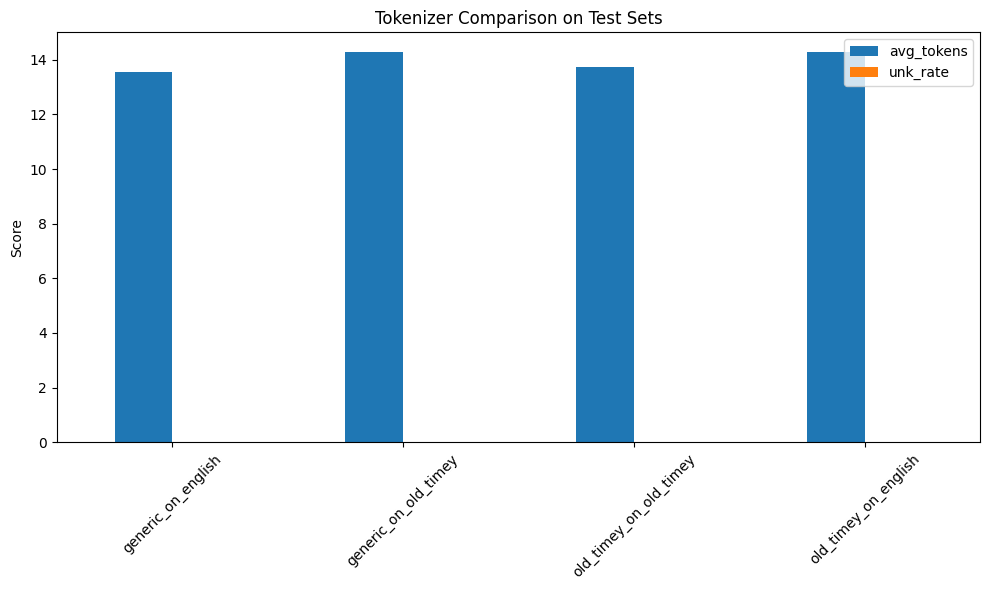

Evaluation Results (baseline vs old timey specific):
English Scores: {'avg_tokens': 13.552, 'unk_rate': 0.0} and {'avg_tokens': 14.284, 'unk_rate': 0.0}
Old-Timey Scores: {'avg_tokens': 14.29, 'unk_rate': 0.0} and {'avg_tokens': 13.748, 'unk_rate': 0.0}


In [284]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame(results).T
df.plot(kind="bar", figsize=(10,6))
plt.ylabel("Score")
plt.title("Tokenizer Comparison on Test Sets")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(OUTPUTS / "plots" / "comparison.png")
plt.show()

print("Evaluation Results (baseline vs old timey specific):")
print(f"English Scores: {results['generic_on_english']} and {results['old_timey_on_english']}")
print(f"Old-Timey Scores: {results['generic_on_old_timey']} and {results['old_timey_on_old_timey']}")

# Function to mass-compare without plots 

In [285]:
def tune_vocab_size(vs):
    generic_tokenizer = train_bpe_tokenizer(
        input_files=modern_paths,
        output_path=OUTPUTS / "tokenizers" / "tokenizer_generic_modern.json",
        vocab_size=vs
    )

    old_timey_tokenizer = train_bpe_tokenizer(
        input_files=old_timey_paths,
        output_path=OUTPUTS / "tokenizers" / "tokenizer_old_timey.json",
        vocab_size=vs
    )

    def evaluate_tokenizer(tokenizer, test_file: Path, n_lines: int = 500):
        with open(test_file, 'r', encoding='utf-8') as f:
            lines = [line.strip() for line in f if line.strip()][:n_lines]

        encoded = [tokenizer.encode(line) for line in lines]

        avg_tokens = sum(len(e.ids) for e in encoded) / len(encoded)
        unk_count = sum(e.ids.count(tokenizer.token_to_id("[UNK]")) for e in encoded)
        unk_rate = unk_count / sum(len(e.ids) for e in encoded)

        return {"avg_tokens": avg_tokens, "unk_rate": unk_rate}
    
    results = {}

    results["generic_on_english"] = evaluate_tokenizer(
        generic_tokenizer, TEST_DIR / "test_english.txt"
    )
    results["generic_on_old_timey"] = evaluate_tokenizer(
        generic_tokenizer, TEST_DIR / "test_old_timey.txt"
    )

    results["old_timey_on_old_timey"] = evaluate_tokenizer(
        old_timey_tokenizer, TEST_DIR / "test_old_timey.txt"
    )
    results["old_timey_on_english"] = evaluate_tokenizer(
        old_timey_tokenizer, TEST_DIR / "test_english.txt"
    )

    print("Evaluation Results (baseline vs old timey specific):")
    print(f"English Scores: {results['generic_on_english']} and {results['old_timey_on_english']}")
    print(f"Old-Timey Scores: {results['generic_on_old_timey']} and {results['old_timey_on_old_timey']}")

# Run it!

In [286]:
for x in [100, 500, 1000, 2000, 5000, 10000, 30000, 50000]:
    print(f"Showing results for vocab size: {[x]}.")
    tune_vocab_size(x)

Showing results for vocab size: [100].
Evaluation Results (baseline vs old timey specific):
English Scores: {'avg_tokens': 42.534, 'unk_rate': 0.0} and {'avg_tokens': 39.93, 'unk_rate': 0.0}
Old-Timey Scores: {'avg_tokens': 42.002, 'unk_rate': 0.0} and {'avg_tokens': 39.276, 'unk_rate': 0.0}
Showing results for vocab size: [500].
Evaluation Results (baseline vs old timey specific):
English Scores: {'avg_tokens': 22.616, 'unk_rate': 0.0} and {'avg_tokens': 22.64, 'unk_rate': 0.0}
Old-Timey Scores: {'avg_tokens': 22.878, 'unk_rate': 0.0} and {'avg_tokens': 22.88, 'unk_rate': 0.0}
Showing results for vocab size: [1000].
Evaluation Results (baseline vs old timey specific):
English Scores: {'avg_tokens': 19.39, 'unk_rate': 0.0} and {'avg_tokens': 19.884, 'unk_rate': 0.0}
Old-Timey Scores: {'avg_tokens': 20.252, 'unk_rate': 0.0} and {'avg_tokens': 19.99, 'unk_rate': 0.0}
Showing results for vocab size: [2000].
Evaluation Results (baseline vs old timey specific):
English Scores: {'avg_tokens'

# Analysis:

These results are certainly interesting.

They show us numerous things.

To begin, an expected observation is that the average tokens created when the vocab size for all of these show a sharp decrease with increase in vocab size. This directly proves the hypothesized negative correlation between average tokens used in a sentence and vocab size (bigger vocab size = fewer tokens used in sentences). That being said, the larger vocab sizes are slower.

Another observation was the fact that the generic english scores for the baseline were ALWAYS better than the old timey version. This includes the notable observation that eventually the average tokens for generic english plateau. While this occurs, the old timey one still (very slowly) decreases average tokens used. Furthermore, the gap between how worse it was seemed to lessen as vocab size increased. This is likely because as the vocab got bigger, it just went on to add more generic english words instead of relatively having a higher percentage of tokens being related to old timey english. 

As for the old timey scores, as hoped, the old timey version performed better always. Also notable with this is that the old timey version continued to decrease in average token length while the generic one stalled. This likely proved that the different count of books was not ideal. Similarly, the old timey model generally improved over the generic model more as the vocab size increased. So, initially, the gap was mostly quite close, but as vocab size increased, it is likely old timey tokens were added instead of generic english tokens, making it more efficient at working with these sentences.

Another interesting observation is that at 10k and below for a vocab size, the performance for avg tokens for general and old timey tests were about the same (meaning there probably wasn't that much of a learned difference). This dramatically changed after 10k for the old time variation, implying that with a larger vocab size, it may be preferable to use variations that have specializations for what you need.

In sum, it seemed that with larger vocabs especially, having some specific variations may generally benefit more than hurt, but this may also be due to more general information being in that language. Another way of looking at these results that may help is in terms of average tokens between the generic score and old timey score for the variations. The specialized version had a better score especially at larger vocab sizes.